In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from IPython.display import Image
import json
from tqdm import tqdm
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import pickle

try:
    from graphviz import Digraph
except:
    ! pip install graphviz
    from graphviz import Digraph

### Functions

In [2]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

In [3]:
# upload to s3
def upload_to_s3(str_local_path, str_bucket_path, str_project):
    boto3.resource('s3').Bucket(str_project).Object(str_bucket_path).upload_file(str_local_path)

### Constants

In [4]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_dirname_output = './output'
str_variant = 'noPTImodel10'

Project: 20231010-gen-xii


### Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Models

In [6]:
list_str_model = [
    '01_ad',
    '02_pricing_pd',
    '03_pricing_lgd',
]

### Flow Chart

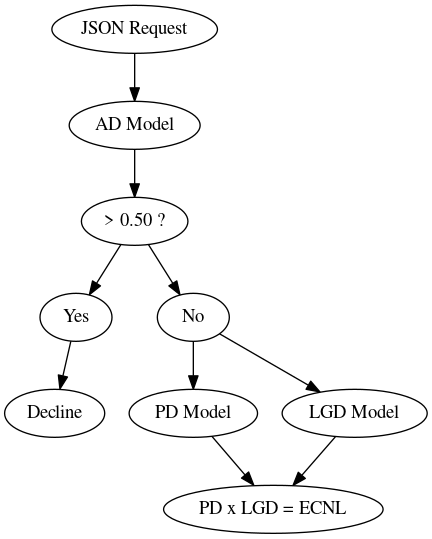

In [7]:
# init
dot = Digraph()

# nodes
dot.node('A', 'JSON Request')
dot.node('B', 'AD Model')
dot.node('C', '> 0.50 ?')
dot.node('D', 'Yes')
dot.node('E', 'No')
dot.node('F', 'Decline')
dot.node('G', 'PD Model')
dot.node('H', 'LGD Model')
dot.node('I', 'PD x LGD = ECNL')

# create lines
dot.edges(['AB','BC','CD','CE','DF','EG','EH','GI','HI'])

# save
str_filename = 'schematic'
str_local_path = f'../02_local_app/static/home/{str_filename}'
dot.render(str_local_path, format='png', cleanup=True)

# display
Image(filename=f'{str_local_path}.png')

### Parser

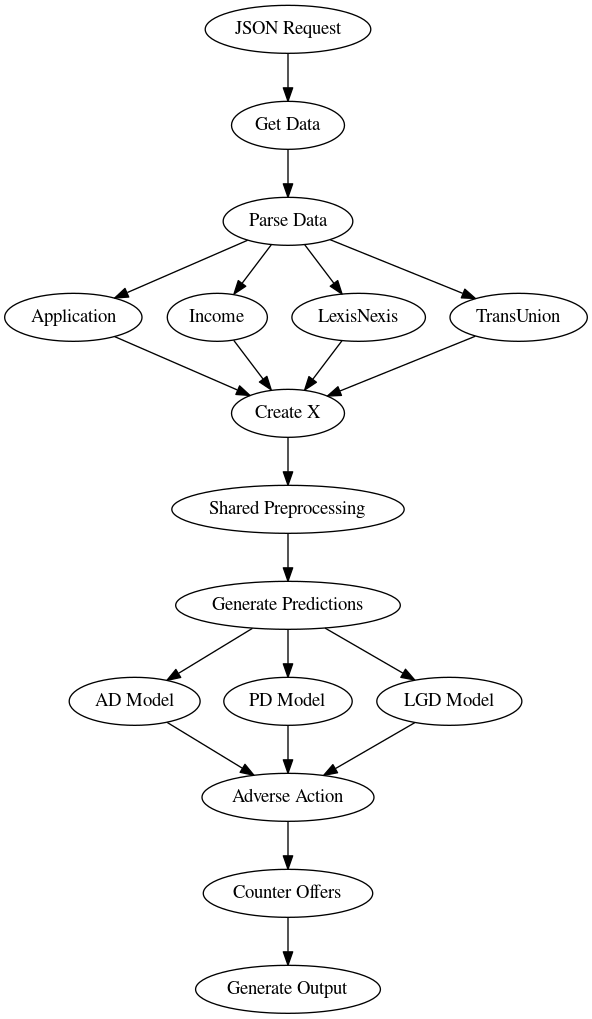

In [8]:
# init
dot = Digraph()

# nodes
dot.node('A', 'JSON Request')
dot.node('B', 'Get Data')
dot.node('C', 'Parse Data')

dot.node('D', 'Application')
dot.node('E', 'Income')
dot.node('F', 'LexisNexis')
dot.node('G', 'TransUnion')

dot.node('H', 'Create X')
dot.node('I', 'Shared Preprocessing')
dot.node('J', 'Generate Predictions')

dot.node('K', 'AD Model')
dot.node('L', 'PD Model')
dot.node('M', 'LGD Model')

dot.node('N', 'Adverse Action')
dot.node('O', 'Counter Offers')
dot.node('P', 'Generate Output')

# create lines
list_edges = [
    'AB',
    'BC',
    
    'CD',
    'CE',
    'CF',
    'CG',
    
    'DH',
    'EH',
    'FH',
    'GH',
    
    'JK',
    'JL',
    'JM',
    
    'HI',
    'IJ',
    
    'KN',
    'LN',
    'MN',
    
    'NO',
    'OP',   
]


dot.edges(list_edges)

# save
str_filename = 'parser_schematic'
str_local_path = f'../02_local_app/static/home/{str_filename}'
dot.render(str_local_path, format='png', cleanup=True)

# display
Image(filename=f'{str_local_path}.png')

### All Features

In [9]:
list_cols_all = []
dict_cols = {}
for str_model in tqdm(list_str_model):
    str_filename = 'df_cols_in_model.csv'
    str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
    # get list of features
    list_cols = list(pd.read_csv(str_uri)['feature'])
    # extend
    list_cols_all.extend(list_cols)
    # assign
    dict_cols[str_model] = list_cols
# rm dups
list_cols_all = list(dict.fromkeys(list_cols_all))
# create df
df = pd.DataFrame({'Feature': list_cols_all})
# create tags
for key, val in dict_cols.items():
    df[key] = df['Feature'].apply(
        lambda x: 1 if x in val else 0,
    )
# get sum
list_cols = list(dict_cols.keys())
df['Sum'] = df[list_cols].sum(axis=1)
# sort
df.sort_values(by='Sum', ascending=False, inplace=True)
# rename
dict_rename = {
    '01_ad': 'AD',
    '02_pricing_pd': 'PD',
    '03_pricing_lgd': 'LGD',
}
df.rename(columns=dict_rename, inplace=True)

# get the AA reason
str_filename = 'df_aa_prod.csv'
str_uri = f's3://{str_project}/ad_hoc/make_adverse_action_dictionary/{str_variant}/{str_filename}'
df_tmp = pd.read_csv(str_uri)
dict_map = dict(zip(df_tmp['feature'], df_tmp['reason']))
# map
df['Reason'] = df['Feature'].map(dict_map)

# get description
str_filename = 'df_descriptions.csv'
str_local_path = f'../../ad_hoc/06_get_descriptions_all/output/{str_variant}/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map = dict(zip(df_tmp['feature'], df_tmp['description']))
dict_map['fltapproveddowntotal__app'] = 'Total down'
# map
df['Description'] = df['Feature'].map(dict_map)

# save
str_filename = 'df_list_cols_all_models.csv'
str_uri = f's3://{str_project}/10_writeup/{str_variant}/home/{str_filename}'
df.to_csv(str_uri, index=False)

# show
df

  0%|          | 0/3 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:275: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)
100%|██████████| 3/3 [00:00<00:00,  6.92it/s]


,Feature,AD,PD,LGD,Sum,Reason,Description
167,re20s__tu,1,1,1,3,"Insufficient credit file, Length of Credit",Months since oldest revolving trade opened
16,strdealershiptrackertype__app,1,1,1,3,Dealer application source,"Franchise, Independent"
116,bc97b__tu,1,1,1,3,Excessive Account Balances,Total open to buy of closed credit cards verif...
5,fltgrossmonthly__income_sum,1,1,1,3,Insufficient income,Total income
75,linka017__tu,1,1,1,3,Excessive Bank Account Closures,Number of checking account closures for cause ...
...,...,...,...,...,...,...,...
142,criminalfelonycount__ln,1,0,0,1,Derogatory public record,Total felony criminal convictions on subject's...
143,g418s__tu,1,0,0,1,Excessive inquiries,Months since most recent auto inquiry
144,co05s__tu,1,0,0,1,Delinquent credit obligations,Total balance of trades that charged-off
146,rvdex02__tu,1,0,0,1,Excessive number of credit obligations or acco...,Most recent quarter year-over-year revolving s...


### Parsing Time

In [10]:
str_filename = 'df_all.csv'
str_local_path = f'../../06_analyze_parser/03_compare/output/{str_variant}/{str_filename}'
df = pd.read_csv(str_local_path)
# rename
dict_rename = {
    'step': 'Step',
    'sec': 'Seconds',
    'prop': 'Proportion',
}
df.rename(columns=dict_rename, inplace=True)

# upload
str_uri = f's3://{str_project}/10_writeup/{str_variant}/home/{str_filename}'
df.to_csv(str_uri, index=False)

# show
df

,Step,Seconds,Proportion,Type
0,Get Data,0.000005,0.000007,Single
1,Parse Data,0.126424,0.177973,Single
2,Create X,0.029837,0.042002,Single
3,Preprocessing,0.417155,0.587249,Single
4,Predictions,0.028372,0.039941,Single
5,Adverse Action,0.107366,0.151145,Single
6,Generate Output,0.001196,0.001683,Single
7,Get Data,0.000006,0.000008,Codebtor
8,Parse Data,0.096831,0.133198,Codebtor
9,Create X,0.029209,0.040178,Codebtor


### Parser, API Script, Functions Script, and Preprocessing Script

In [11]:
# parser
str_filename = 'cls_parser.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'05_parser/01_single/{str_variant}/{str_filename}'
# download
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# save locally
str_destination = f'../02_local_app/{str_filename}'
shutil.move(str_local_path, str_destination)

'../02_local_app/cls_parser.pkl'

In [12]:
# api
str_filename = 'api.py'
str_local_path = f'../../07_api/01_flask_app/app/{str_filename}'
str_destination = f'../02_local_app/{str_filename}'
shutil.copyfile(str_local_path, str_destination)

'../02_local_app/api.py'

In [13]:
# api
str_filename = 'functions.py'
str_local_path = f'../../07_api/01_flask_app/app/{str_filename}'
str_destination = f'../02_local_app/{str_filename}'
shutil.copyfile(str_local_path, str_destination)

'../02_local_app/functions.py'

In [14]:
# preprocessing script
str_filename = 'preprocessing.py'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
# download
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# save locally
str_destination = f'../02_local_app/{str_filename}'
shutil.move(str_local_path, str_destination)

'../02_local_app/preprocessing.py'

### Entire Process

100%|██████████| 3/3 [00:00<00:00, 38.41it/s]


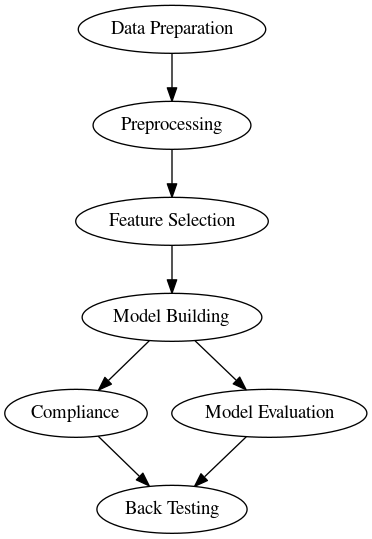

In [15]:
for str_model in tqdm(list_str_model):
    # init
    dot = Digraph()

    # nodes
    dot.node('A', 'Data Preparation')
    dot.node('B', 'Preprocessing')
    dot.node('C', 'Feature Selection')
    dot.node('D', 'Model Building')
    dot.node('E', 'Compliance')
    dot.node('F', 'Model Evaluation')
    dot.node('G', 'Back Testing')

    # create lines
    list_edges = [
        'AB',
        'BC',
        'CD',
        'DE',
        'DF',
        'EG',
        'FG',
    ]
    dot.edges(list_edges)

    # save
    str_filename = 'overall_schematic'
    str_local_path = f'../02_local_app/static/{str_model}/{str_filename}'
    dot.render(str_local_path, format='png', cleanup=True)

# display
Image(filename=f'{str_local_path}.png')

### Data Preparation

100%|██████████| 3/3 [00:00<00:00, 40.25it/s]


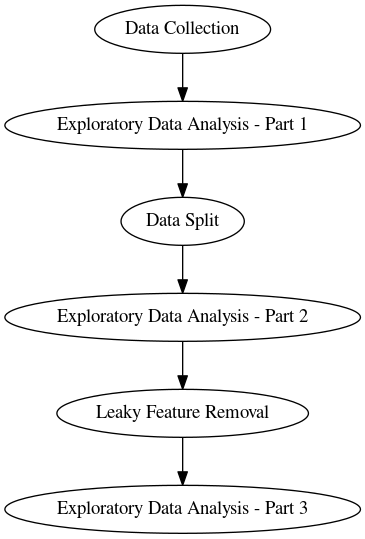

In [16]:
for str_model in tqdm(list_str_model):
    # init
    dot = Digraph()

    # nodes
    dot.node('A', 'Data Collection')
    dot.node('B', 'Exploratory Data Analysis - Part 1')
    dot.node('C', 'Data Split')
    dot.node('D', 'Exploratory Data Analysis - Part 2')
    dot.node('E', 'Leaky Feature Removal')
    dot.node('F', 'Exploratory Data Analysis - Part 3')

    # create lines
    dot.edges(['AB','BC','CD','DE','EF'])

    # save
    str_filename = 'data_prep_schematic'
    str_local_path = f'../02_local_app/static/{str_model}/{str_filename}'
    dot.render(str_local_path, format='png', cleanup=True)

# display
Image(filename=f'{str_local_path}.png')

### EDA Part 1

In [17]:
for str_model in tqdm(list_str_model):
    str_filename = 'dict_df_info.json'
    str_local_path = f'../../{str_model}/01_data_prep/02_eda_pt_1/output/{str_filename}'
    dict_df_info = json.load(open(str_local_path, 'r'))
    df = pd.DataFrame(dict_df_info, index=[0])
    df.columns = ['Rows','Columns','Total Obs.','Min. Date','Max. Date','Target Mean','Proportion Missing']
    df['Data Set'] = 'All'
    df = df[['Data Set','Rows','Columns','Min. Date','Max. Date','Proportion Missing','Target Mean']]

    # upload
    str_filename = 'df_eda_1.csv'
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 31.68it/s]


,Data Set,Rows,Columns,Min. Date,Max. Date,Proportion Missing,Target Mean
0,All,20498,2492,2013-10-01 07:28:54.833000,2019-12-31 14:06:40.040000,0.218734,0.602092


### Target 1

 67%|██████▋   | 2/3 [00:06<00:02,  2.85s/it]

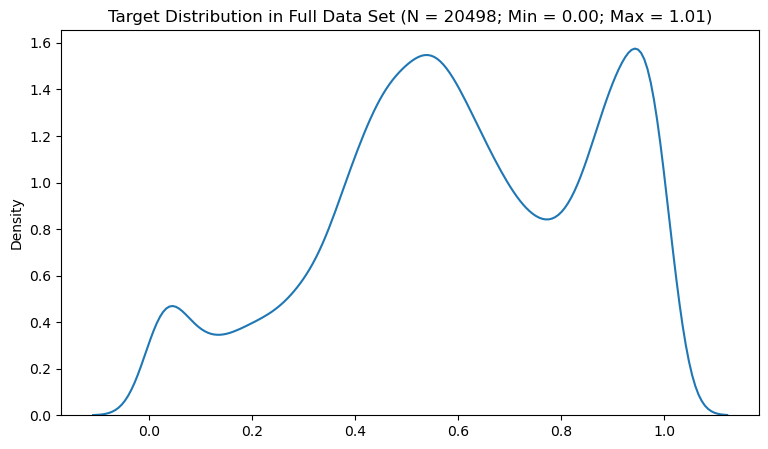

100%|██████████| 3/3 [00:07<00:00,  2.44s/it]


,uniqueid,Target
11,3.996697e+14,0.985462
12,3.996697e+14,0.985462
19,3.935850e+14,0.272984
20,3.935850e+14,0.272984
21,3.935950e+14,0.434160
...,...,...
186164,3.943776e+14,0.939958
186165,3.944564e+14,0.754292
186166,3.947080e+14,0.543776
186168,3.948725e+14,0.981076


In [18]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_raw.gzip'
    str_uri = f's3://{str_project}/{str_model}/01_data_prep/01_data_collection/output/{str_filename}'
    list_cols = [
        'uniqueid',
        'target',
    ]
    df = pd.read_parquet(str_uri, columns=list_cols)
    # rename
    dict_rename = {
        'target': 'Target',
    }
    df.rename(columns=dict_rename, inplace=True)
    # logic
    if 'lgd' not in str_model: # make df
        # upload
        str_filename = 'df_target_1.csv'
        str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
        df.to_csv(str_uri, index=False)
    else: # make plot
        # get n
        int_n = df.shape[0]
        # get min/max
        flt_min = df['Target'].min()
        flt_max = df['Target'].max()
        # show distribution
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Target Distribution in Full Data Set (N = {int_n}; Min = {flt_min:0.2f}; Max = {flt_max:0.2f})')
        sns.kdeplot(list(df['Target']), ax=ax)
        # save
        str_filename = 'plt_target_1.png'
        str_local_path = f'../02_local_app/static/03_pricing_lgd/{str_filename}'
        plt.savefig(str_local_path, bbox_inches='tight')
        # show
        plt.show()

# show
df

### EDA Part 2

In [19]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_info_summary.csv'
    str_local_path = f'../../{str_model}/01_data_prep/04_eda_pt_2/output/{str_filename}'
    df = pd.read_csv(str_local_path)
    # rename
    dict_rename = {
        'Prop. NaN': 'Proportion Missing',
    }
    df.rename(columns=dict_rename, inplace=True)

    # subset
    list_cols = [
        'Data Set',
        'Rows',
        'Columns',
        'Min. Date',
        'Max. Date',
        'Proportion Missing',
        'Target Mean',
    ]
    df = df[list_cols]

    # upload
    str_filename = 'df_eda_2.csv'
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 22.56it/s]


,Data Set,Rows,Columns,Min. Date,Max. Date,Proportion Missing,Target Mean
0,Train,12298,2492,2013-10-01 07:28:54.833000,2017-01-25 15:57:47.713000,0.239948,0.654582
1,Valid,4100,2492,2017-01-25 15:57:47.713000,2018-09-19 09:21:04.723000,0.136786,0.659692
2,Test,4100,2492,2018-09-19 11:21:27.960000,2019-12-31 14:06:40.040000,0.237049,0.612249


### Target 2

 67%|██████▋   | 2/3 [00:03<00:01,  1.82s/it]

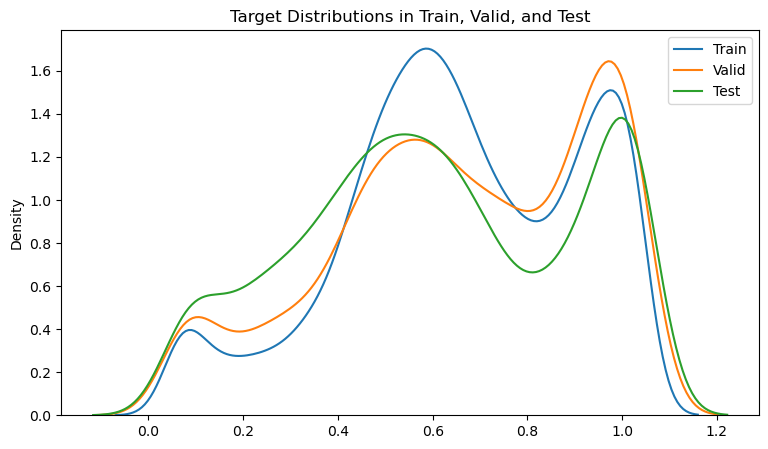

100%|██████████| 3/3 [00:05<00:00,  1.81s/it]


,Data Set,Target
0,Train,"[0.6691820032571019, 0.6691820032571019, 0.588..."
1,Valid,"[0.6471101693284724, 0.62658916062362, 0.62658..."
2,Test,"[0.42813889439305963, 0.42813889439305963, 0.4..."


In [20]:
for str_model in tqdm(list_str_model):
    list_dict_row = []
    for str_df in ['train','valid','test']:
        str_filename = f'df_{str_df}_raw.gzip'
        str_uri = f's3://{str_project}/{str_model}/01_data_prep/03_train_valid_test_split/{str_filename}'
        list_cols = [
            'uniqueid',
            'target',
        ]
        df = pd.read_parquet(str_uri, columns=list_cols)
        # dict row
        dict_row = {
            'Data Set': str_df.capitalize(),
            'Target': list(df['target']),
        }
        list_dict_row.append(dict_row)
    # make df
    df = pd.DataFrame(list_dict_row)
    # logic
    if 'lgd' not in str_model: # make df
        # train
        ser_val_counts_train = pd.Series(df['Target'].iloc[0]).value_counts(normalize=True)
        # valid 
        ser_val_counts_valid = pd.Series(df['Target'].iloc[1]).value_counts(normalize=True)
        # test
        ser_val_counts_test = pd.Series(df['Target'].iloc[2]).value_counts(normalize=True)
        # make df
        df = pd.DataFrame({
            'Value': [0, 1],
            'Train': ser_val_counts_train.values,
            'Valid': ser_val_counts_valid.values,
            'Test': ser_val_counts_test.values,
        })
        # melt for grouped plot
        df = df.melt(id_vars='Value', var_name='Data Set', value_name='Proportion')
        # upload
        str_filename = 'df_target_2.csv'
        str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
        df.to_csv(str_uri, index=False)
    else: # make plot
        # convert to dictionary
        dict_target = dict(zip(df['Data Set'], df['Target']))
        # show distribution
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Target Distributions in Train, Valid, and Test')
        for str_df, list_target in dict_target.items():
            sns.kdeplot(list_target, ax=ax, label=str_df)
        # legend
        plt.legend()
        # save
        str_filename = 'plt_target_2.png'
        str_local_path = f'../02_local_app/static/03_pricing_lgd/{str_filename}'
        plt.savefig(str_local_path, bbox_inches='tight')
        # show
        plt.show()

# show
df   

### Leaky Features

In [21]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_cols_bad.csv'
    str_local_path = f'../../{str_model}/01_data_prep/05_leaky_features/03_leaky/output/{str_filename}'
    df = pd.read_csv(str_local_path)

    # rename
    dict_rename = {
        'feature': 'Feature',
        'from_nan': 'Threshold Missing',
        'from_df': 'No Variance or Redundant',
        'from_name': 'Name',
        'sum': 'Sum',
    }
    df.rename(columns=dict_rename, inplace=True)

    # upload
    str_filename = 'df_leaky.csv'
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 16.28it/s]


,Feature,Threshold Missing,No Variance or Redundant,Name,Sum
0,dtmstampcreation__base,1,1,1,3
1,dtmapproved__tu,1,1,1,3
2,permid__tu,1,1,1,3
3,partyid__tu,1,1,1,3
4,acctid__tu,1,1,1,3
...,...,...,...,...,...
961,linkc030__tu,1,0,0,1
962,linkc040__tu,1,0,0,1
963,linkc042__tu,1,0,0,1
964,linkc036__tu,1,0,0,1


### Drift Analysis

In [22]:
# for str_model in tqdm(list_str_model):
#     str_filename = 'df_drift.csv'
#     str_uri = f's3://{str_project}/{str_model}/01_data_prep/05_leaky_features/05_drift_detection/{str_filename}'
#     df = pd.read_csv(str_uri)
#     # rename
#     dict_rename = {
#         'col': 'Feature',
#         'prop_diff': 'Proportion Difference',
#     }
#     df.rename(columns=dict_rename, inplace=True)
#     # upload
#     str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'

# # show
# df

### EDA Part 3

In [23]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_info_summary.csv'
    str_local_path = f'../../{str_model}/01_data_prep/06_eda_pt_3/output/{str_filename}'
    df = pd.read_csv(str_local_path)
    # rename
    dict_rename = {
        'Prop. NaN': 'Proportion Missing',
    }
    df.rename(columns=dict_rename, inplace=True)
    # subset
    list_cols = [
        'Data Set',
        'Rows',
        'Columns',
        'Min. Date',
        'Max. Date',
        'Proportion Missing',
        'Target Mean',
    ]
    df = df[list_cols]

    # upload
    str_filename = 'df_eda_3.csv'
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 23.35it/s]


,Data Set,Rows,Columns,Min. Date,Max. Date,Proportion Missing,Target Mean
0,Train,12298,1528,2013-10-01 07:28:54.833000,2017-01-25 15:57:47.713000,0.065907,0.654582
1,Valid,4100,1528,2017-01-25 15:57:47.713000,2018-09-19 09:21:04.723000,0.076391,0.659692
2,Test,4100,1528,2018-09-19 11:21:27.960000,2019-12-31 14:06:40.040000,0.080429,0.612249


### Preprocessing

100%|██████████| 3/3 [00:00<00:00, 66.48it/s]


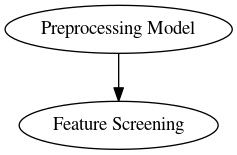

In [24]:
for str_model in tqdm(list_str_model):
    # init
    dot = Digraph()

    # nodes
    dot.node('A', 'Preprocessing Model')
    dot.node('B', 'Feature Screening')

    # create lines
    dot.edges(['AB'])

    # save
    str_filename = 'preprocessing_schematic'
    str_local_path = f'../02_local_app/static/{str_model}/{str_filename}'
    dot.render(str_local_path, format='png', cleanup=True)

# display
Image(filename=f'{str_local_path}.png')

### Final List of Features

In [25]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_cols_final.csv'
    str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/00_preprocessing/03_get_list_of_cols/{str_filename}'
    df = pd.read_csv(str_uri)
    # rm ids and target
    list_cols = list(df['feature'])
    list_cols_ignore = [
        'applicationdate__app',
        'year_month',
        'target',
        'uniqueid',
    ]
    list_cols = [col for col in list_cols if col not in list_cols_ignore]
    df = pd.DataFrame({'Feature': list_cols})

    # upload
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 10.89it/s]


,Feature
0,linkf189__tu
1,linkf060__tu
2,linkf045__tu
3,linkb012__tu
4,intopenbktype__app
...,...
1518,ENG-applicationdate__app_quarter
1519,ENG-payment_to_income
1520,ENG-loan_to_value
1521,ENG-vehicle_age


### Feature Selection Schematic

100%|██████████| 3/3 [00:00<00:00, 56.26it/s]


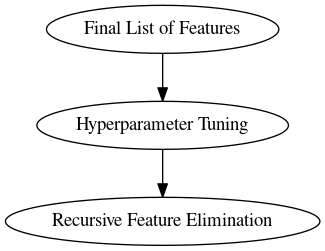

In [26]:
for str_model in tqdm(list_str_model):
    # init
    dot = Digraph()

    # nodes
    dot.node('A', 'Final List of Features')
    dot.node('B', 'Hyperparameter Tuning')
    dot.node('C', 'Recursive Feature Elimination')

    # create lines
    dot.edges(['AB','BC'])

    # save
    str_filename = 'feat_select_schematic'
    str_local_path = f'../02_local_app/static/{str_model}/{str_filename}'
    dot.render(str_local_path, format='png', cleanup=True)

# display
Image(filename=f'{str_local_path}.png')

### Feature Selection

In [27]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_list_features.csv'
    str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/01_lambda_get_starting_feats/{str_filename}'
    df = pd.read_csv(str_uri)
    # rename
    dict_rename =  {
        'feature': 'Feature',
    }
    df.rename(columns=dict_rename, inplace=True)

    # upload
    str_filename = 'df_list_starting_feats.csv'
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 11.73it/s]


,Feature
0,linkf189__tu
1,linkf060__tu
2,linkf045__tu
3,linkb012__tu
4,intopenbktype__app
...,...
1395,addrinputtimeoldest__ln
1396,assetpropevercount__ln
1397,addrcurrentsubjectowned__ln
1398,alertregulatorycondition__ln


### Tuning 1

In [28]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_tuning.csv'
    str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/03_lambda_concat_tuning/{str_filename}'
    df = pd.read_csv(str_uri)
    dict_rename = {
        'iteration': 'Iteration',
        'learning_rate': 'Learning Rate',
        'flt_eval_metric_train': 'Train Score',
        'flt_eval_metric_valid': 'Valid Score',
        'diff': 'Difference',
        'best_iteration': 'Best Iteration',
    }
    df.rename(columns=dict_rename, inplace=True)
    # subset
    list_cols = [
        'Learning Rate',
        'Train Score',
        'Valid Score',
    ]
    df = df[list_cols]

    # sort
    df.sort_values(by='Learning Rate', ascending=True, inplace=True)

    # upload
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 12.62it/s]


,Learning Rate,Train Score,Valid Score
2,0.0010,0.246111,0.274083
0,0.0111,0.241352,0.273943
1,0.0212,0.241872,0.274046
3,0.0312,0.238618,0.274465
4,0.0413,0.242814,0.274645
...,...,...,...
95,0.9587,0.350981,0.374571
96,0.9688,0.352431,0.375981
97,0.9788,0.353866,0.377376
98,0.9889,0.355313,0.378784


### Recursive Feature Elimination

In [29]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_iterative_feat_select.csv'
    str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/04_batch_feature_selection/results/{str_filename}'
    df = pd.read_csv(str_uri)
    dict_rename = {
        'iteration': 'Iteration',
        'flt_eval_metric_train': 'Train Score',
        'flt_eval_metric_valid': 'Valid Score',
        'n_feats': 'Number of Features',
        'best_iteration': 'Best Iteration',
    }
    df.rename(columns=dict_rename, inplace=True)
    # subset
    list_cols = [
        'Iteration',
        'Train Score',
        'Valid Score',
        'Number of Features',
    ]
    df = df[list_cols]

    # sort
    df.sort_values(by='Iteration', ascending=True, inplace=True)
    # upload
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 11.70it/s]


,Iteration,Train Score,Valid Score,Number of Features
0,0,0.241352,0.273943,1398
1,1,0.237729,0.272619,334
2,2,0.232200,0.271670,197
3,3,0.233033,0.271147,131
4,4,0.232908,0.270756,103
5,5,0.233277,0.270810,88
6,6,0.233244,0.270505,83
7,7,0.233933,0.270662,80
8,8,0.233494,0.270488,77
9,9,0.233577,0.270620,76


### Model Schematic

100%|██████████| 3/3 [00:00<00:00, 30.07it/s]


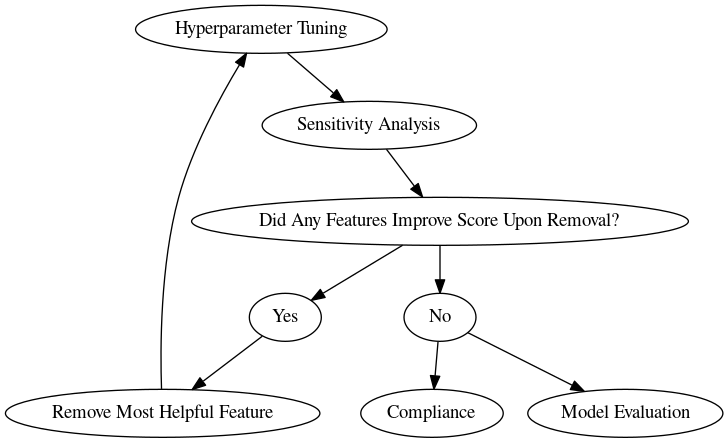

In [30]:
for str_model in tqdm(list_str_model):
    # init
    dot = Digraph()

    # nodes
    dot.node('A', 'Hyperparameter Tuning')
    dot.node('B', 'Sensitivity Analysis')
    dot.node('C', 'Did Any Features Improve Score Upon Removal?')
    dot.node('D', 'Yes')
    dot.node('E', 'No')
    dot.node('F', 'Remove Most Helpful Feature')
    dot.node('G', 'Compliance')
    dot.node('H', 'Model Evaluation')

    # create lines
    list_edges = [
        'AB',
        'BC',
        'CD',
        'CE',
        'DF',
        'EG',
        'EH',
        'FA',
    ]
    dot.edges(list_edges)

    # save
    str_filename = 'model_schematic'
    str_local_path = f'../02_local_app/static/{str_model}/{str_filename}'
    dot.render(str_local_path, format='png', cleanup=True)

# display
Image(filename=f'{str_local_path}.png')

### Tuning - 2

In [31]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_tuning.csv'
    str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/03_lambda_concat_tuning/{str_filename}'
    df = pd.read_csv(str_uri)
    dict_rename = {
        'learning_rate': 'Learning Rate',
        'flt_eval_metric_train': 'Train Score',
        'flt_eval_metric_valid': 'Valid Score',
    }
    df.rename(columns=dict_rename, inplace=True)
    # subset
    list_cols = [
        'Learning Rate',
        'Train Score',
        'Valid Score',
    ]
    df = df[list_cols]

    # sort
    df.sort_values(by='Learning Rate', ascending=True, inplace=True)

    # upload
    str_filename = 'df_tuning_2.csv'
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 10.21it/s]


,Learning Rate,Train Score,Valid Score
11,0.0010,0.246636,0.273308
0,0.0111,0.233599,0.270460
1,0.0212,0.229651,0.270649
2,0.0312,0.230944,0.270778
4,0.0413,0.235054,0.271412
3,0.0514,0.224721,0.271363
5,0.0615,0.230167,0.271647
6,0.0716,0.233219,0.271978
7,0.0816,0.231158,0.272099
8,0.0917,0.235911,0.272925


### Sensitivity Analysis

In [32]:
# factors for $$ lost (not accurate)

# auc factor
flt_auc = 0.001
flt_loss_auc = 55000
flt_factor_auc = flt_loss_auc / flt_auc
print(f'Factor AUC: {flt_factor_auc}')

# rmse factor
flt_rmse = 0.01
flt_loss_rmse = 162000
flt_factor_rmse = flt_loss_rmse / flt_rmse
print(f'Factor RMSE: {flt_factor_rmse}')

Factor AUC: 55000000.0
Factor RMSE: 16200000.0


In [33]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_sensitivity.csv'
    str_local_path = f'../../{str_model}/02_model/03_summary/04_{str_variant}/output/{str_filename}' # not dynamic
    df = pd.read_csv(str_local_path)
    dict_rename = {
        'feature': 'Feature',
        'flt_eval_metric_train': 'Train Score',
        'flt_eval_metric_valid': 'Valid Score',
        'flt_score_to_beat': 'Score to Beat',
        'performance': 'Performance Loss',
        'description': 'Description'
    }
    df.rename(columns=dict_rename, inplace=True)
    # make a rank and rank prop column
    int_nrows = df.shape[0]
    df['Rank'] = list(range(1, int_nrows+1))
    df['Rank Prop.'] = df['Rank'] / int_nrows

    # logic
    if 'lgd' not in str_model:
        # create dollars lost
        df['Dollars'] = (flt_factor_auc * df['Performance Loss']).round(2)
    else:
        df['Dollars'] = (flt_factor_rmse * df['Performance Loss']).round(2)
    # subset
    list_cols = [
        'Rank',
        'Rank Prop.',
        'Feature',
        'Train Score',
        'Valid Score',
        'Score to Beat',
        'Performance Loss',
        'Dollars',
        'Description',
    ]
    df = df[list_cols]

    # upload
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 18.21it/s]


,Rank,Rank Prop.,Feature,Train Score,Valid Score,Score to Beat,Performance Loss,Dollars,Description
0,1,0.013158,dealerstate__app,0.234871,0.271346,0.27046,-0.000887,-14363.53,Dealer State
1,2,0.026316,rev232__tu,0.239404,0.271322,0.27046,-0.000862,-13967.32,Aggregate Excess Payment for Revolving account...
2,3,0.039474,jt02s__tu,0.237482,0.271117,0.27046,-0.000658,-10655.24,Number of open joint trades
3,4,0.052632,jt20s__tu,0.237028,0.271018,0.27046,-0.000558,-9039.36,Months since oldest joint trade opened
4,5,0.065789,ENG-vehicle_age,0.235703,0.270966,0.27046,-0.000506,-8203.10,Age of vehicle (years)
...,...,...,...,...,...,...,...,...,...
71,72,0.947368,per222__tu,0.233575,0.270514,0.27046,-0.000054,-879.22,Average total Payment Ratio for Personal Loan ...
72,73,0.960526,g202b__tu,0.233637,0.270508,0.27046,-0.000048,-779.82,Total open to buy of closed trades verified in...
73,74,0.973684,all253__tu,0.233737,0.270504,0.27046,-0.000045,-722.69,Average Aggregate Excess Payment for All accou...
74,75,0.986842,fr21s__tu,0.233520,0.270503,0.27046,-0.000043,-700.72,Months since most recent finance revolving tra...


### Partial Dependence Plots

  0%|          | 0/3 [00:00<?, ?it/s]

ENG-loan_to_value.png not found for model 01_ad


 33%|███▎      | 1/3 [00:00<00:00,  3.24it/s]

fltdowncash__app.png not found for model 01_ad
fltgrossmonthly__income_count.png not found for model 02_pricing_pd


100%|██████████| 3/3 [00:00<00:00,  3.28it/s]

fltgrossmonthly__income_count.png not found for model 03_pricing_lgd


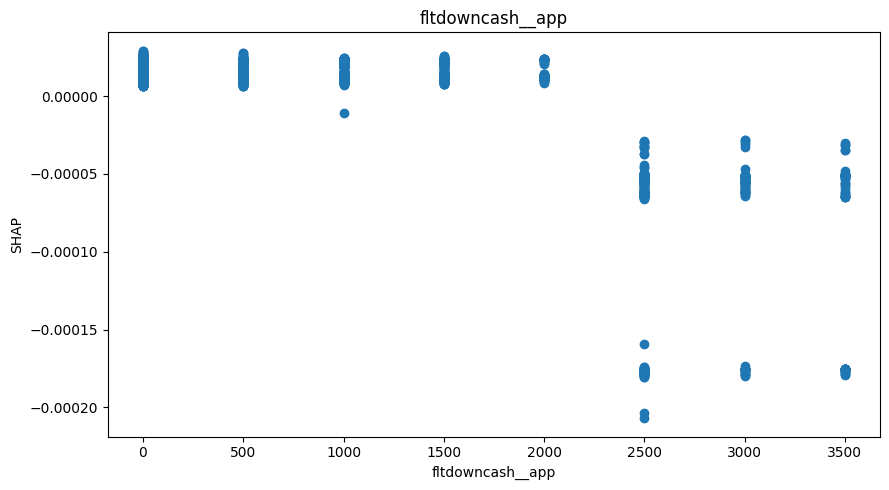

In [34]:
list_cols = [
    'ENG-loan_to_value',
    'fltgrossmonthly__income_sum',
    'fltgrossmonthly__income_count',
    'fltdowncash__app',
]

# pd plots
for str_model in tqdm(list_str_model):
    for col in list_cols:
        try:
            str_filename = f'{col}.png'
            str_local_path = f'../02_local_app/static/{str_model}/{str_filename}'    
            download_from_s3(
                str_local_path=str_local_path, 
                str_bucket_path=f'{str_model}/02_model/{str_variant}/02_model/10_batch_pd_plots_test/plots/{str_filename}', 
                str_project=str_project,
            )
        except:
            print(f'{str_filename} not found for model {str_model}')

# show
Image(filename=str_local_path)

### Disparate Impact - Plots

100%|██████████| 3/3 [00:00<00:00,  7.02it/s]


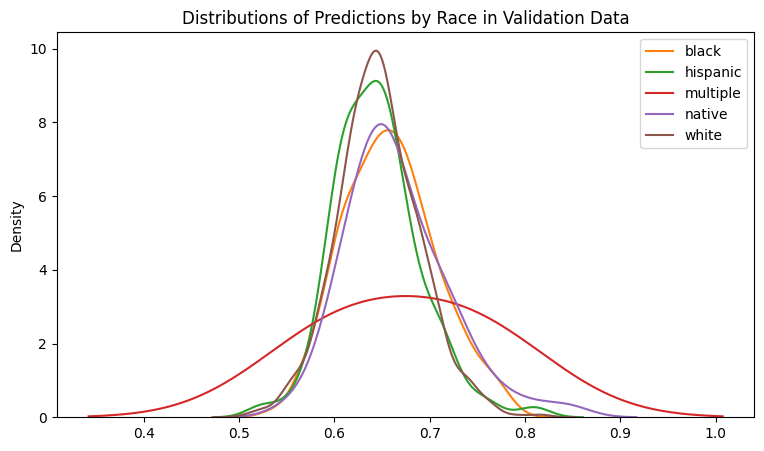

In [35]:
# race
for str_model in tqdm(list_str_model):
    # race
    str_filename = 'plt_yhat_dist_race.png'
    str_local_path = f'../02_local_app/static/{str_model}/{str_filename}'    
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=f'{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}', 
        str_project=str_project,
    )

# show
Image(filename=str_local_path)

100%|██████████| 3/3 [00:00<00:00, 12.33it/s]


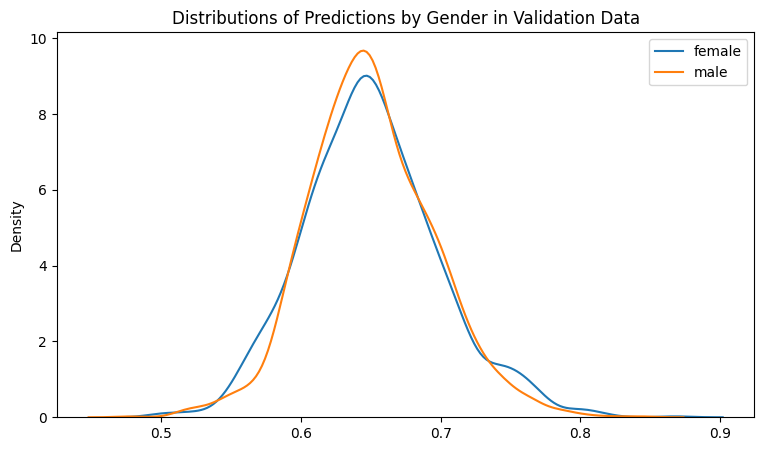

In [36]:
# gender
for str_model in tqdm(list_str_model):
    str_filename = 'plt_yhat_dist_gender.png'
    str_local_path = f'../02_local_app/static/{str_model}/{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=f'{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}', 
        str_project=str_project,
    )

# show
Image(filename=str_local_path)

100%|██████████| 3/3 [00:00<00:00, 13.37it/s]


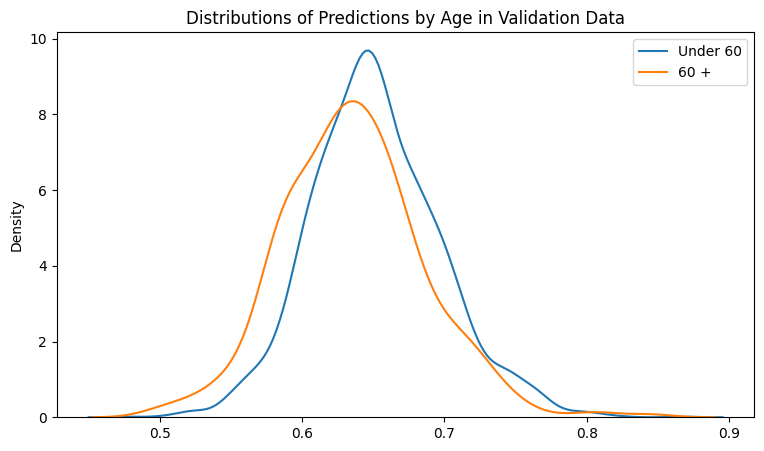

In [37]:
# age
for str_model in tqdm(list_str_model):
    str_filename = 'plt_yhat_dist_age.png'
    str_local_path = f'../02_local_app/static/{str_model}/{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=f'{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}', 
        str_project=str_project,
    )

# show
Image(filename=str_local_path)

### Disparate Impact - Sensitivity

In [38]:
for str_model in tqdm(list_str_model):
    try:
        # top features
        list_str_filename = [
            'df_feat_imp_race.csv',
            'df_feat_imp_gender.csv',
            'df_feat_imp_age.csv',
        ]
        dict_list_feats = {}
        list_list_features = []
        for str_filename in list_str_filename:
            str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}'
            list_features = list(pd.read_csv(str_uri)['feature'])[:10]
            str_filename_tmp = str_filename[:-4].split('_')[-1].capitalize()
            dict_list_feats[str_filename_tmp] = list_features
            list_list_features.append(list_features)
        # flatten list
        list_features = [item for sublist in list_list_features for item in sublist]
        # rm dups
        list_features = list(dict.fromkeys(list_features))

        # make df
        df = pd.DataFrame({'Feature': list_features})
        
        # create tags
        for key, val in dict_list_feats.items():
            df[key] = df['Feature'].apply(
                lambda x: 1 if x in val else 0,
            )
        # sum
        list_cols = list(dict_list_feats.keys())
        df['Sum'] = df[list_cols].sum(axis=1)
        # sort
        df.sort_values(by='Sum', ascending=False, inplace=True)

        # join sensisitivity
        str_filename = 'df_sensitivity.csv'
        str_local_path = f'../../{str_model}/02_model/03_summary/04_{str_variant}/output/{str_filename}'
        df_tmp = pd.read_csv(str_local_path)
        dict_rename = {
            'feature': 'Feature',
            'flt_eval_metric_train': 'Train Score',
            'flt_eval_metric_valid': 'Valid Score',
            'flt_score_to_beat': 'Score to Beat',
            'performance': 'Performance Loss',
            'description': 'Description'
        }
        df_tmp.rename(columns=dict_rename, inplace=True)
        
        # make a rank and rank prop column
        int_nrows = df_tmp.shape[0]
        df_tmp['Rank'] = list(range(1, int_nrows+1))
        df_tmp['Rank Prop.'] = df_tmp['Rank'] / int_nrows
        
        # logic
        if 'lgd' not in str_model:
            # create dollars lost
            df_tmp['Dollars'] = (flt_factor_auc * df_tmp['Performance Loss']).round(2)
        else:
            df_tmp['Dollars'] = (flt_factor_rmse * df_tmp['Performance Loss']).round(2)
        
        # subset
        list_cols = [
            'Rank',
            'Rank Prop.',
            'Feature',
            'Train Score',
            'Valid Score',
            'Score to Beat',
            'Performance Loss',
            'Dollars',
            'Description',
        ]
        df_tmp = df_tmp[list_cols]
        
        # join
        df = pd.merge(
            left=df,
            right=df_tmp,
            on='Feature',
            how='left',
        )
        # sort
        df.sort_values(by='Performance Loss', ascending=True, inplace=True)
        
        # reorder
        list_cols = [
            'Rank',
            'Rank Prop.',
            'Feature',
            'Race',
            'Gender',
            'Age',
            'Sum',
            'Train Score',
            'Valid Score',
            'Score to Beat',
            'Performance Loss',
            'Dollars',
            'Description',
        ]
        df = df[list_cols].copy()

        # upload
        str_filename = 'df_disparate.csv'
        str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
        df.to_csv(str_uri, index=False)
    except Exception as e:
        print(e)

# show
df

100%|██████████| 3/3 [00:00<00:00,  5.60it/s]


,Rank,Rank Prop.,Feature,Race,Gender,Age,Sum,Train Score,Valid Score,Score to Beat,Performance Loss,Dollars,Description
3,1,0.013158,dealerstate__app,1,0,1,2,0.234871,0.271346,0.27046,-0.000887,-14363.53,Dealer State
6,3,0.039474,jt02s__tu,0,1,1,2,0.237482,0.271117,0.27046,-0.000658,-10655.24,Number of open joint trades
1,4,0.052632,jt20s__tu,1,1,1,3,0.237028,0.271018,0.27046,-0.000558,-9039.36,Months since oldest joint trade opened
0,7,0.092105,linkf185__tu,1,1,1,3,0.234496,0.270917,0.27046,-0.000457,-7407.78,Age of newest inquiry ONLINE LENDER
4,10,0.131579,fltgrossmonthly__income_sum,0,1,1,2,0.233847,0.270862,0.27046,-0.000402,-6516.50,Total income
7,11,0.144737,au36s__tu,1,0,1,2,0.235438,0.270835,0.27046,-0.000376,-6084.97,Months since most recent auto delinquency
2,14,0.184211,addronfilecount__ln,1,1,1,3,0.233707,0.270805,0.27046,-0.000346,-5601.89,Total number of addresses found on file in sub...
5,15,0.197368,criminalnonfelonytimenewest__ln,0,1,1,2,0.234357,0.270789,0.27046,-0.000330,-5340.07,Time (in months) since most recently recorded ...
9,19,0.250000,bankruptcychapter__ln,1,0,1,2,0.234187,0.270774,0.27046,-0.000314,-5090.56,Indicates bankruptcy chapter of most recent ba...
8,23,0.302632,addrinputavmvalue12month__ln,1,0,1,2,0.233795,0.270742,0.27046,-0.000283,-4576.79,Indicates input address AVM value on file 12 m...


### Adverse Action Reasons

In [39]:
for str_model in tqdm(list_str_model):
    str_filename = 'df_aa_prod.csv'
    str_uri = f's3://{str_project}/ad_hoc/make_adverse_action_dictionary/{str_variant}/{str_filename}'
    df = pd.read_csv(str_uri)

    # rename
    dict_rename = {
        'feature': 'Feature',
        'reason': 'Reason',
        'definition': 'Defintition',
    }
    df.rename(columns=dict_rename, inplace=True)

    # upload
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 14.41it/s]


,Feature,Reason,model,description,Change Reason/Comment
0,inquiryshortterm12month__ln,Excessive inquiries,gen_xii,Indicates subject has one or more LexisNexis p...,NaN
1,bkc84__tu,Excessive Account Balances,gen_xii,Months since a Bankcard trade last exceeded 90...,NaN
2,linkf165__tu,Excessive number of sources for phone number o...,gen_xii,Number of distinct home phones within last 18 ...,NaN
3,rt21s__tu,"Insufficient credit file, Length of Credit",gen_xii,Months since most recent retail trade opened,NaN
4,lienjudgmenttaxcount__ln,Tax or other liens,gen_xii,"Total federal, state, and county tax liens on ...",NaN
...,...,...,...,...,...
533,linkt002__tu,Short time in area,genxii_v2,Number of months at current address,NaN
534,ENG-vehicle_age,Insufficient collateral,genxii_v2,Vehicle age,NaN
535,addrcurrentsubjectowned__ln,No mortgage loans reported or too few active m...,genxii_v2,Subject owns current address,NaN
536,addrpreviouslengthofres__ln,Short time in area,genxii_v2,Length of residency in previous residence,NaN


### Model Evaluation

In [40]:
for str_model in tqdm(list_str_model):
    # valid
    str_filename = 'df_valid_model_eval_metrics.csv'
    str_local_path = f'../../{str_model}/02_model/03_summary/04_{str_variant}/output/{str_filename}'
    df_valid = pd.read_csv(str_local_path)

    # test
    str_filename = 'df_test_model_eval_metrics.csv'
    str_local_path = f'../../{str_model}/02_model/03_summary/04_{str_variant}/output/{str_filename}'
    df_test = pd.read_csv(str_local_path)

    # join
    df = pd.merge(
        left=df_valid,
        right=df_test,
        on='train',
        how='left',
    )
    
    # logic cause lgd is different
    if 'lgd' not in str_model:
        # set metric values
        list_metrics = [
            'Accuracy',
            'Precision',
            'Recall',
            'F1',
            'ROC AUC',
            'Precision-Recall AUC',
            'Log Loss',
        ]
    else:
        # set metric values
        list_metrics = [
            'Explained Variance',
            'Mean Absolute Error',
            'Mean Squared Error',
            'Root Mean Squared Error',
        ]
    
    # assign
    df['Metric'] = list_metrics

    # reorder
    df = df[['Metric','train','valid','test']]

    # rename
    dict_rename = {
        'train': 'Train Score',
        'valid': 'Valid Score',
        'test': 'Test Score',
    }
    df.rename(columns=dict_rename, inplace=True)

    # upload
    str_filename = 'df_metrics.csv'
    str_uri = f's3://{str_project}/10_writeup/{str_variant}/{str_model}/{str_filename}'
    df.to_csv(str_uri, index=False)

# show
df

100%|██████████| 3/3 [00:00<00:00, 17.80it/s]


,Metric,Train Score,Valid Score,Test Score
0,Explained Variance,0.135551,0.036291,0.035833
1,Mean Absolute Error,0.187747,0.225421,0.239518
2,Mean Squared Error,0.054569,0.073148,0.081160
3,Root Mean Squared Error,0.233599,0.270460,0.284886


### Model Eval

100%|██████████| 3/3 [00:00<00:00,  3.94it/s]

Cannot find file plt_roc_auc_test.png in model 03_pricing_lgd


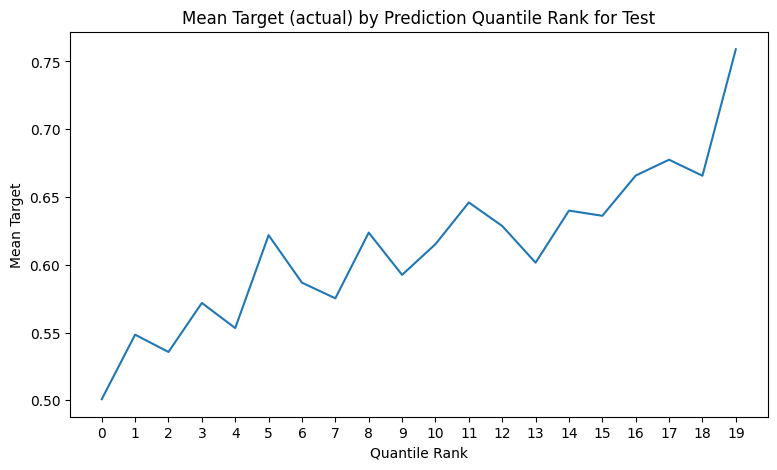

In [41]:
list_str_filename = [
    'plt_dist_yhat.png',
    'plt_roc_auc_test.png',
    'plt_lift_test.png',
]
for str_model in tqdm(list_str_model):
    for str_filename in list_str_filename:
        try:
            # download
            str_local_path = f'../02_local_app/static/{str_model}/{str_filename}'    
            str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
            download_from_s3(
                str_local_path=str_local_path, 
                str_bucket_path=str_bucket_path, 
                str_project=str_project,
            )
        except:
            print(f'Cannot find file {str_filename} in model {str_model}')

# show
Image(filename=str_local_path)

### Back Testing

100%|██████████| 4/4 [00:00<00:00, 5564.58it/s]


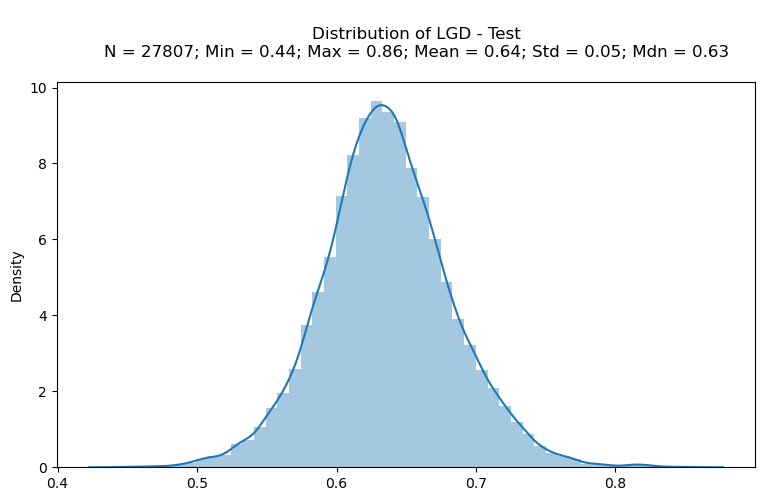

In [42]:
# get test predictions (from PD test data)
for str_model in tqdm(['ECNL','AD','PD','LGD']):
    str_filename = f'plt_dist_{str_model}.png'
    str_local_path = f'../../ad_hoc/01_get_predictions/02_lift_charts/output/{str_variant}/distplots/{str_filename}'
    # filename
    str_filename_out = 'plt_test_predictions.png'
    # copy file
    if str_model == 'ECNL':
        str_model_out = 'home'
    elif str_model == 'AD':
        str_model_out = '01_ad'
    elif str_model == 'PD':
        str_model_out = '02_pricing_pd'
    elif str_model == 'LGD':
        str_model_out = '03_pricing_lgd'
    else:
        pass
    str_destination = f'../02_local_app/static/{str_model_out}/{str_filename_out}' 
    shutil.copyfile(str_local_path, str_destination)

# show
Image(filename=str_local_path)

100%|██████████| 4/4 [00:00<00:00, 6257.82it/s]


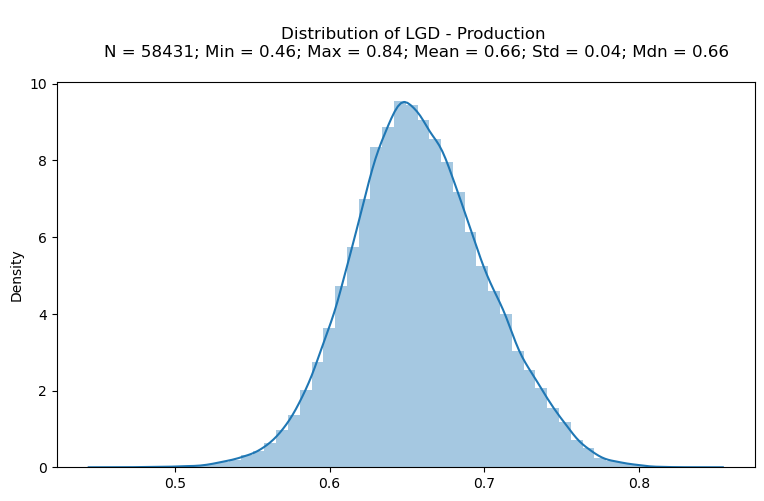

In [43]:
# get production predictions
for str_model in tqdm(['ecnl','ad','pd','lgd']):
    # logic
    if str_model == 'ecnl':
        str_filename = 'plt_dist_pricing_ecnl.png'
    elif str_model == 'ad':
        str_filename = 'plt_dist_yhat_ad.png'
    elif str_model == 'pd':
        str_filename = 'plt_dist_yhat_pricing_pd.png'
    elif str_model == 'lgd':
        str_filename = 'plt_dist_yhat_pricing_lgd.png'
    else:
        pass
    str_local_path = f'../../08_retro_scoring/07_analysis/01_get_predictions/output/{str_variant}/{str_filename}'
    # filename
    str_filename_out = 'plt_prod_predictions.png'
    # copy file
    if str_model == 'ecnl':
        str_model_out = 'home'
    elif str_model == 'ad':
        str_model_out = '01_ad'
    elif str_model == 'pd':
        str_model_out = '02_pricing_pd'
    elif str_model == 'lgd':
        str_model_out = '03_pricing_lgd'
    else:
        pass
    str_destination = f'../02_local_app/static/{str_model_out}/{str_filename_out}' 
    shutil.copyfile(str_local_path, str_destination)

# show
Image(filename=str_local_path)

In [44]:
# get the production distributions and the tier proportions
list_str_filename = [
    'plt_kde_prod.png',
    'df_tier_dist.csv',
]
for str_filename in tqdm(list_str_filename):
    str_local_path = f'../../08_retro_scoring/08_segment_distributions/03_make_plots/output/{str_variant}/{str_filename}'
    str_destination = f'../02_local_app/static/home/{str_filename}' 
    shutil.copyfile(str_local_path, str_destination)

100%|██████████| 2/2 [00:00<00:00, 4495.50it/s]


In [45]:
# get line plot of the scores
list_str_filename = [
    'plt_corresponding_scores_prod.png',
    'plt_swap_heatmap.png',
]
for str_filename in tqdm(list_str_filename):
    str_local_path = f'../../08_retro_scoring/09_swap_in_swap_out_plot/02_create_plot/output/{str_variant}/{str_filename}'
    str_destination = f'../02_local_app/static/home/{str_filename}' 
    shutil.copyfile(str_local_path, str_destination)

100%|██████████| 2/2 [00:00<00:00, 4253.86it/s]
